In [1]:
include("CRD_STA.jl")
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using ProgressMeter
using Plots

In [5]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval,eigvec
end

eigsol (generic function with 1 method)

In [9]:
N_cheb = 49
Ro = -1
Tw = 1
Mr = 0.1
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = 0.075
num = 1
omega = 0.01975
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
R = 400
Ma = Mr/R

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/LFeTa/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/LFeTa/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/LFeTa/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/LFeTa/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/LFeTa/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/LFeTa/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/LFeTa/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

0.00025

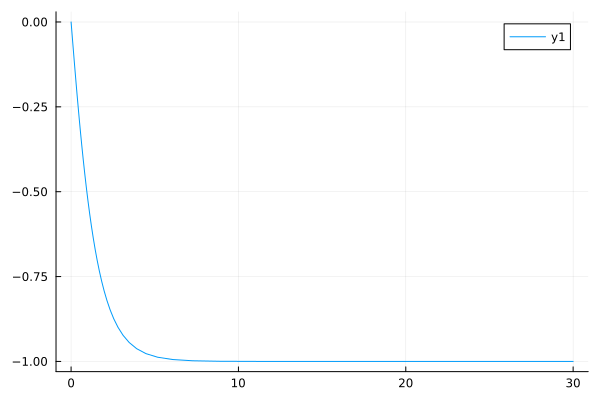

In [10]:
plot(z,G)

In [11]:
eigval1,eigvec1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.5,num)
eigval1

1-element Vector{ComplexF64}:
 0.5596942379672912 - 0.005621702018214867im

In [19]:
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
A,B,C = ALST_Operater1(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
del = abs.(A2) - abs.(C)
findall(x->abs(x)>1e-1,del)

CartesianIndex{2}[]

In [ ]:
A,B,C = ALST_Operater(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
nep = PEP([A',B',C']); 
eig1,eigvec = iar(nep,σ = 0.55 , neigs = 10 ,maxit = 500,tol=1e-10)
eig1

10-element Vector{ComplexF64}:
 0.20547132187555084 - 0.2692826340641515im
  0.5287457557953885 + 0.334305296418807im
  0.4308815759338419 + 0.19793115237176961im
 0.32618978375413543 + 0.07647420294447126im
  0.3444035177678409 - 0.5906027091326504im
  0.6224865199567476 + 0.48770116513064077im
  0.7121511150425668 + 0.657208314085023im
 0.20137245019528105 + 0.2677313855554654im
   0.776985711563519 + 0.7906353940775711im
  0.1294625811274694 - 0.1777244237265134im

In [ ]:
A,B,C = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
nep = PEP([A,B,C]); 
eig1,eigvec = iar(nep,σ = 0.6 , neigs = 1 ,maxit = 500,tol=1e-10)
eig1

1-element Vector{ComplexF64}:
 0.6821830353144817 - 0.20507455901270225im

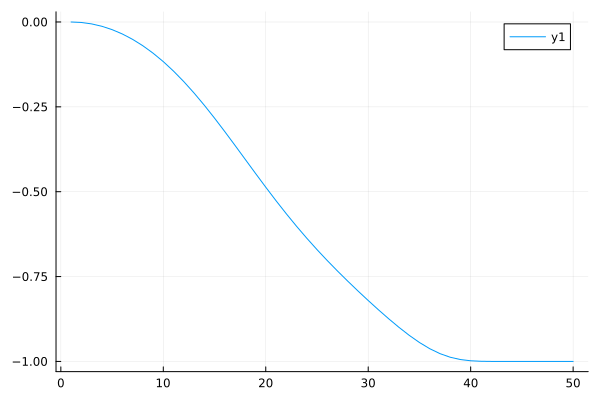

In [137]:
plot(G)

In [17]:
function ALST_Operater1(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
      if Ro == -1
          Ro = 1
      end

        eye = I(N_cheb + 1)
        Zero = zeros(N_cheb + 1,N_cheb + 1)

        A0_11 = rho .* eye
        A1_11 = im * R * rho .* eye
        A2_11 = Zero

        A0_12 = im * R * be * rho .* eye
        A1_12 = Zero
        A2_12 = Zero

        A0_13 = - R * rho .* (D*rho) .* eye - R * rho.^2 .* D
        A1_13 = Zero
        A2_13 = Zero

        A0_14 = im * R * (be * G .- omega) .* eye + 2 * F .* eye  - (D * rho) .* H .* eye - rho .* H .* D
        A1_14 = im * R * F .* eye
        A2_14 = Zero

        A0_15 = Zero
        A1_15 = Zero
        A2_15 = Zero

        A0_21 = im * R * rho .* (be * G .* eye - omega .* eye) + Ro * (rho .* F .* eye - 2 * rho .* (D*rho) .* H .* eye - rho.^2 .* (D*H) .* eye) + be^2 * T .* eye - D2 * rho .* eye - Ro * rho.^2 .* H .* D - 2 * (D*rho) .* D - rho .* D2
        A1_21 = im * R * rho .* F .* eye
        A2_21 = (lam + 2*T) .* eye

        A0_22 = -rho .* (Ro * G .+ Co) .* eye
        A1_22 = be * (lam .+ T).*eye
        A2_22 = Zero

        A0_23 = R * rho.^2 .* (D * F) .* eye
        A1_23 = im * ((D*rho).*lam .+ rho .* (D*lam) .+ (1 .+ lam .* rho) .* D) .* eye - im * rho .*(D*T) .*eye
        A2_23 = Zero

        A0_24 = rho .* D2 * F .* eye
        A1_24 = im * R * (gamma * Ma^2)^(-1) * T .* eye
        A2_24 = Zero

        A0_25 = rho .* (D*rho) .* (D*F) .* eye + rho.^2 .*(D*F) .* D
        A1_25 = im * R * (gamma * Ma^2)^(-1) * rho .* eye
        A2_25 = Zero

        A0_31 = rho.*(Ro*G .+ Co) .*eye
        A1_31 = be * (lam .+ T).* eye
        A2_31 = Zero

        A0_32 = im * R * rho .* ( be * G .* eye - omega .* eye) + Ro * (rho .* F .* eye - 2 * rho .* (D*rho) .* H .* eye - rho.^2 .* (D*H) .* eye) + be^2 * (lam + 2*T) .* eye - D2 * rho .* eye- Ro * rho.^2 .* H .* D - 2 * (D*rho) .* D - rho .* D2
        A1_32 = im * R * rho .* F .* eye
        A2_32 = T .* eye

        A0_33 = R * rho.^2 .* (D*G) .* eye - im * be * rho .* (D*T) .* eye + im * be * ( (D*rho).*lam .+ rho .* (D*lam) .+  (1 .+ lam .* rho) .* D) .* eye
        A1_33 = Zero
        A2_33 = Zero

        A0_34 = F .* (Ro * G .+ Co) .* eye+ Ro * rho .* H .* (D*G) .* eye + (gamma * Ma^2)^(-1) .* im * be * R * T .* eye
        A1_34 = Zero
        A2_34 = Zero

        A0_35 = rho .* (D*rho) .* (D*G) .* eye + im * be * R * (gamma * Ma^2)^(-1) * rho .* eye + rho.^2 .* (D * G) .* D
        A1_35 = Zero
        A2_35 = Zero

        A0_41 = Zero
        A1_41 = im* D * rho .* lam .* eye + im * (1 .+ rho.*lam) .* D
        A2_41 = Zero

        A0_42 = -im * be * (rho .* D * lam .* eye) + im * be *  ((D*rho).*lam .+ rho .* (D*lam)) .* eye  + im * be * (1 .+ rho.*lam) .* D
        A1_42 = Zero
        A2_42 = Zero

        A0_43 = R * rho .* (im * be * G .- im * omega) .* eye  - 2 * Ro * rho .* (D*rho).* H .* eye + be^2 * T .* eye + D2 * (2 * rho .+ lam .* rho.^2) .* eye - Ro * rho.^2 .* H .* D - 4 * (D*rho).*D - 2 * D*lam .* rho.^2 .* D - 4 * (lam) .* rho .*(D*rho).*D - rho .* (2 .+ rho .*lam) .* D2
        A1_43 = im * R * rho .* F .* eye
        A2_43 = T .* eye

        A0_44 =  - R * (gamma * Ma^2)^(-1) * (D*rho) .* T .* eye + R * (gamma * Ma^2)^(-1) * rho .* T .* D
        A1_44 = Zero
        A2_44 = Zero

        A0_45 = -im * be * rho .* (D*G) .* eye - (gamma * Ma^2)^(-1) * R * rho .*(D*rho) .* eye - R *(gamma * Ma^2)^(-1) *rho.^2 .* D
        A1_45 = -im * rho .* (D*F) .* eye
        A2_45 = Zero

        A0_51 = 2 * (gamma-1) * Ma^2 * (rho .* (D2*F) .+ (D*rho).*(D*F)).*eye + 2 * (gamma - 1) * Ma^2 * rho .* (D*F) .* D
        A1_51 = Zero
        A2_51 = Zero

        A0_52 = 2 * (gamma-1) * Ma^2 * (rho .* (D2*G) .+ (D*rho).*(D*G)).*eye + 2 * (gamma - 1) * Ma^2 * rho .* (D*G) .* D
        A1_52 = Zero
        A2_52 = Zero

        A0_53 = -2 * (gamma - 1) * Ma^2 * im * be * (D*G) .* eye + R * rho.^2 .* (D*T) .* eye
        A1_53 = -2 * (gamma - 1) * Ma^2 * im * (D*F) .* eye
        A2_53 = Zero

        A0_54 = (gamma - 1)/(gamma) * (-im * R * T .* (be * G.*eye - omega .* eye) + (D*rho) .* H .* T .* eye + rho .* (D*H) .* T .* eye + rho .* H .* T .* D) + rho .* H .* (D*T) .* eye
        A1_54 = -(gamma - 1)/(gamma) * (im * R * F.* T .* eye)
        A2_54 = Zero

        A0_55 = R * rho .* (im * be * G .* eye - im * omega .* eye) + kappa * be^2 .* eye - (gamma - 1)/(gamma) * (im * be * R .* rho .* G .* eye - im * omega * R .* rho .* eye - rho .* (D*rho) .* H .* eye - rho.^2 .* (D*H).* eye) -(2 * rho .* (D*rho) .* H .* eye + rho.^2 .* (D*H) .* eye) - (gamma - 1) * Ma^2 * rho.^2 .* ((D*F).^2 .+ (D*G).^2) .* eye - (1/sigma) * (rho .* (D*rho) .* (D*T) .+(D*rho).*(D*T).+ rho.^2 .* (D2 * T) .+ rho .* (D2 * T) ).* eye -D2*(kappa .* rho.^2) .* eye - rho.^2 .* H .* D - (1/sigma) * rho.^2 .* (D*T) .* D + (gamma-1)/(gamma) * rho.^2 .* H .* D - 4 * rho .* (D*rho) .* kappa .* D - 2 * rho.^2 .* (D*kappa) .* D - rho.^2 .* kappa .* D2
        A1_55 = im * R * rho .* F .* eye -(gamma-1)/(gamma) * (im * R .* rho .* F) .* eye
        A2_55 = kappa .* eye

        A = [A0_11 A0_12 A0_13 A0_14 A0_15 ; A0_21 A0_22 A0_23 A0_24 A0_25 ; A0_31 A0_32 A0_33 A0_34 A0_35 ; A0_41 A0_42 A0_43 A0_44 A0_45 ; A0_51 A0_52 A0_53 A0_54 A0_55]
        B = [A1_11 A1_12 A1_13 A1_14 A1_15 ; A1_21 A1_22 A1_23 A1_24 A1_25 ; A1_31 A1_32 A1_33 A1_34 A1_35 ; A1_41 A1_42 A1_43 A1_44 A1_45 ; A1_51 A1_52 A1_53 A1_54 A1_55]
        C = [A2_11 A2_12 A2_13 A2_14 A2_15 ; A2_21 A2_22 A2_23 A2_24 A2_25 ; A2_31 A2_32 A2_33 A2_34 A2_35 ; A2_41 A2_42 A2_43 A2_44 A2_45 ; A2_51 A2_52 A2_53 A2_54 A2_55]
        
        A = A[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
        B = B[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
        C = C[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,3N_cheb + 4,4N_cheb + 4,4N_cheb + 5,5N_cheb + 5))]
  
        return A,B,C
end

ALST_Operater1 (generic function with 1 method)